### Here it plots the H1 anatomical images

In [1]:
import sys, os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy.integrate import odeint
from scipy.optimize import minimize, differential_evolution
from scipy.stats import mannwhitneyu
import joblib
from pathlib import Path
from collections import defaultdict

# ── Paths ─────────────────────────────────────────────────────────────────────
try:
    DATA_DIR = Path(__file__).resolve().parent
except NameError:
    DATA_DIR = Path(os.getcwd())   # Jupyter fallback
sys.path.insert(0, str(DATA_DIR))
from lib_roi_masks import f_get_roi_masks, NX, NY

# ── Experiment constants ───────────────────────────────────────────────────────
SCAN_DURATION_SEC = 280          # acquisition time per scan [s]
SCAN_DURATION_MIN = SCAN_DURATION_SEC / 60.0
TISSUES = ['TibialisAnt', 'Gastrocnemius', 'Soleus']   # tissues used in flux fitting
WEEKS   = ['basal', 'w3', 'w6', 'w9']
RESULTS_FILENAME = 'fit_results_MRI_fluxes_vlk_fixed_input.joblib.xz'

# ── Fixed (literature-inspired, provisional for hindlimb) pool sizes ─────────
# Glc_cell = 8 mM  — effective total tissue glucose pool seen by the DMI voxel.
#   Skeletal muscle has a substantial extracellular/interstitial component near
#   plasma glucose levels, so DMI likely sees a mixed tissue-scale glucose pool.
#
# Glx and L remain effective hindlimb pool surrogates rather than firmly measured
# constants in this dataset; they should be revisited by sensitivity analysis.
#
# Because plasma measurements are unavailable, the labelled plasma glucose
# driver is held fixed as G*_p(t) = a1 * exp(-kp * t) with a1 = 35.0 mM and
# kp = 0.020 min^-1 for all fits. In Lu et al. 2017, a1 ~ 22 mM and 
# injection is 1.3g/kg; in our case, it is 2.0 g/kg, so a1 = 35 mM 
# is a reasonable starting point.
#
# KT is NOT fixed here — it is a shared free parameter (see BOUNDS_SHARED).
#   Literature range: 5.8 ± 2.0 mM (PMC12695439) or 6.4 ± 4.4 mM (PMC5669347).
#   Fitting KT allows the optimizer to account for differences in transporter
#   kinetics across mice and weeks without assuming a single literature value.
#
# V_LK is not fitted independently. It is written explicitly in the ODEs for
# clarity, but computed deterministically as 2*MR_glc - V_out.
#
# KIE correction factors from PMC12695439 can be enabled by replacing 1.0 with
# the reported values (gly=1.042, tca=1.035). They are left neutral by default
# because muscle-specific corrections are not yet established.
FIXED_PARAMS = dict(
    f_gly       = 0.157,
    f_tca       = 0.385,
    Glc_p_total = 8.0,
    Glc_cell    = 8.0,
    L           = 1.5,
    K           = 0.10,
    Glx         = 10.0,
    fv          = 0.0,
    kie_gly     = 1.0,
    kie_tca     = 1.0,
    a1          = 35.0,
    kp          = 0.020,
)

# Shared across all voxels: T_max, V_x, KT
# KT bounds span the literature range with margin; initial value = 5.8 mM.
BOUNDS_SHARED = [
    (0.01, 5.0),    # T_max [mM/min]
    (0.01, 10.0),   # V_x   [mM/min]
    (5,  7.0),   # KT    [mM]  GLUT half-saturation constant (fitted, shared)
]
BOUNDS_PER_VOX = [
    (0.001, 1.0),
    (0.001, 2.0),
    (0.0,   1.0),
]

TISSUE_INIT = {
    'TibialisAnt':   dict(T_max=1.5, V_x=2.0, KT=5.8, MR_glc=0.20, V_TCA=0.10, V_out=0.06),
    'Gastrocnemius': dict(T_max=1.5, V_x=2.0, KT=5.8, MR_glc=0.15, V_TCA=0.20, V_out=0.05),
    'Soleus':        dict(T_max=1.0, V_x=3.0, KT=5.8, MR_glc=0.10, V_TCA=0.40, V_out=0.03),
}

MIN_SIGNAL_MM = 0.3
ROI_RADIUS    = 1

print('Configuration loaded.')
print(f'  Tissues: {TISSUES}')
print(f'  Results file: {RESULTS_FILENAME}')
print(f"  Fixed plasma input: a1={FIXED_PARAMS['a1']:.1f} mM, kp={FIXED_PARAMS['kp']:.3f} min^-1")
print('  Shared free params: T_max, V_x, KT  |  Per-voxel: MR_glc, V_TCA, V_out')
print('  Deterministic V_LK = 2*MR_glc - V_out')


Configuration loaded.
  Tissues: ['TibialisAnt', 'Gastrocnemius', 'Soleus']
  Results file: fit_results_MRI_fluxes_vlk_fixed_input.joblib.xz
  Fixed plasma input: a1=35.0 mM, kp=0.020 min^-1
  Shared free params: T_max, V_x, KT  |  Per-voxel: MR_glc, V_TCA, V_out
  Deterministic V_LK = 2*MR_glc - V_out


In [2]:
data_path = DATA_DIR / 'data_tissue_vals_model_fitting.joblib.xz'
data = joblib.load(data_path)

hash_mouseID_2_df_tissue_val   = data[0]   # single-seed time-series (validation only)
hash_mouseID2group             = data[1]   # {mouseID: 'dia' | 'norm'}
df_image_data                  = data[2]   # 16×16 concentration maps per scan
hash_mouseID2week2maskMap      = data[3]   # {mouseID: {week: 16×16 bool hindlimb mask}}
hash_mouseID2week2H1anatomical = data[4]   # {mouseID: {week: 128×128 ¹H anatomical image}}

# Keep only (mouseID, week) pairs that have both image data and a tissue mask
available_combos = (
    df_image_data[['mouseID', 'week']]
    .drop_duplicates()
    .sort_values(['mouseID', 'week'])
    .values.tolist()
)
available_combos = [
    (mid, wk) for mid, wk in available_combos
    if mid in hash_mouseID2week2maskMap and wk in hash_mouseID2week2maskMap[mid]
]

print(f'Loaded data from {data_path}')
print(f'Valid (mouseID, week) combinations: {len(available_combos)}')
for mid, wk in available_combos:
    grp = hash_mouseID2group.get(mid, '?')
    print(f'  Mouse {mid:3d} ({grp:4s})  week={wk}')


Loaded data from /home/pty/work/DMI_GEM_APBC2026/2_extract_DMI_met/data_tissue_vals_model_fitting.joblib.xz
Valid (mouseID, week) combinations: 16
  Mouse  45 (dia )  week=w9
  Mouse  47 (dia )  week=w3
  Mouse  48 (dia )  week=w3
  Mouse  48 (dia )  week=w6
  Mouse  48 (dia )  week=w9
  Mouse  49 (norm)  week=w3
  Mouse  49 (norm)  week=w9
  Mouse  51 (norm)  week=w6
  Mouse  51 (norm)  week=w9
  Mouse  52 (norm)  week=w6
  Mouse  53 (dia )  week=basal
  Mouse  53 (dia )  week=w3
  Mouse  54 (norm)  week=w6
  Mouse  55 (dia )  week=basal
  Mouse  55 (dia )  week=w9
  Mouse  56 (norm)  week=w9


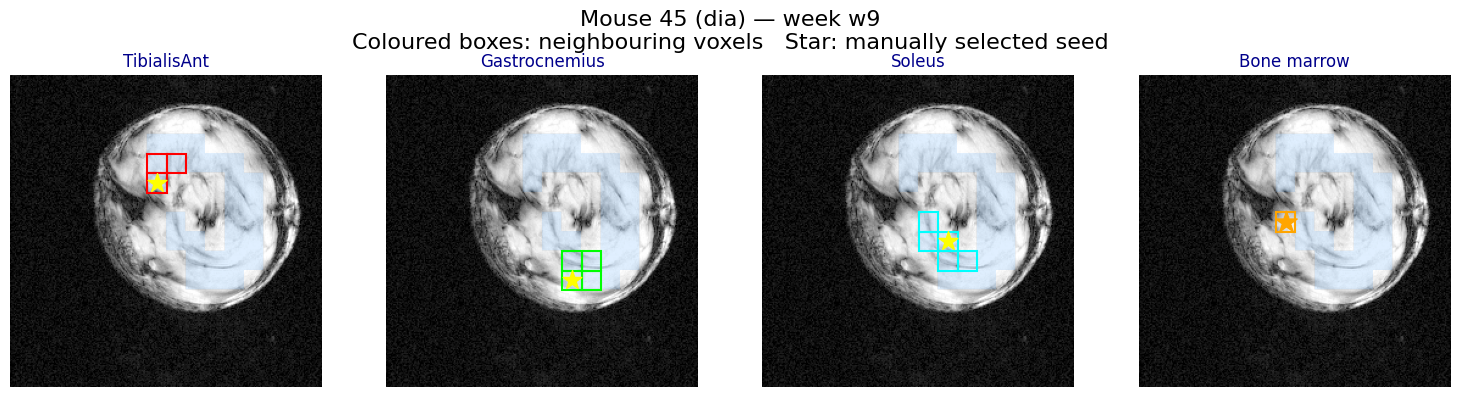

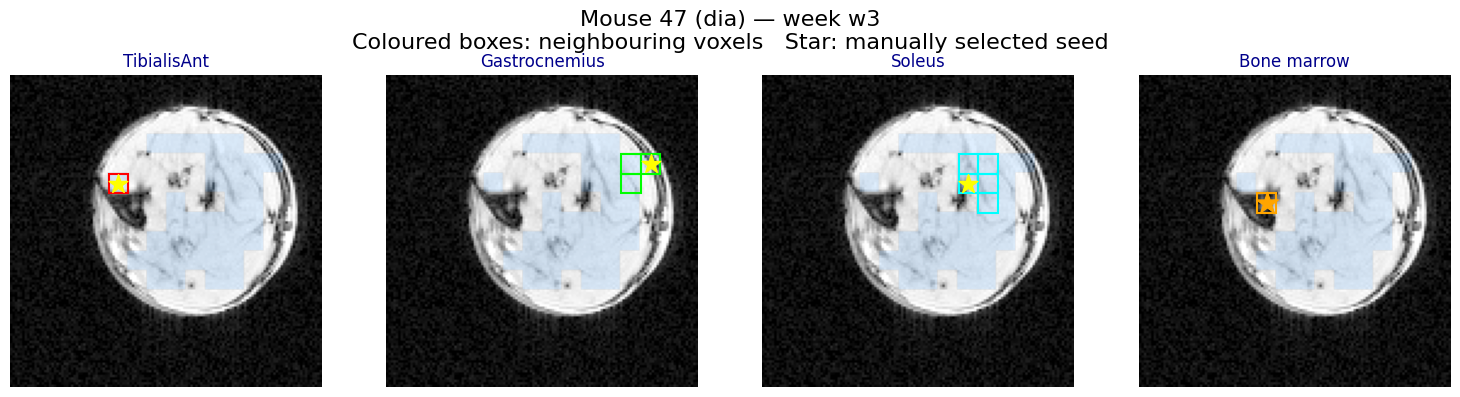

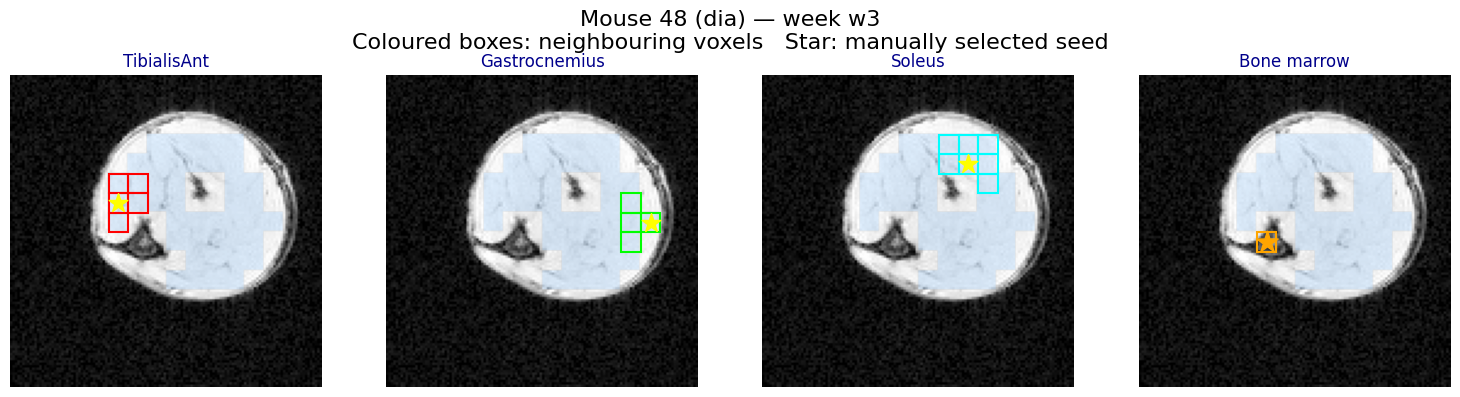

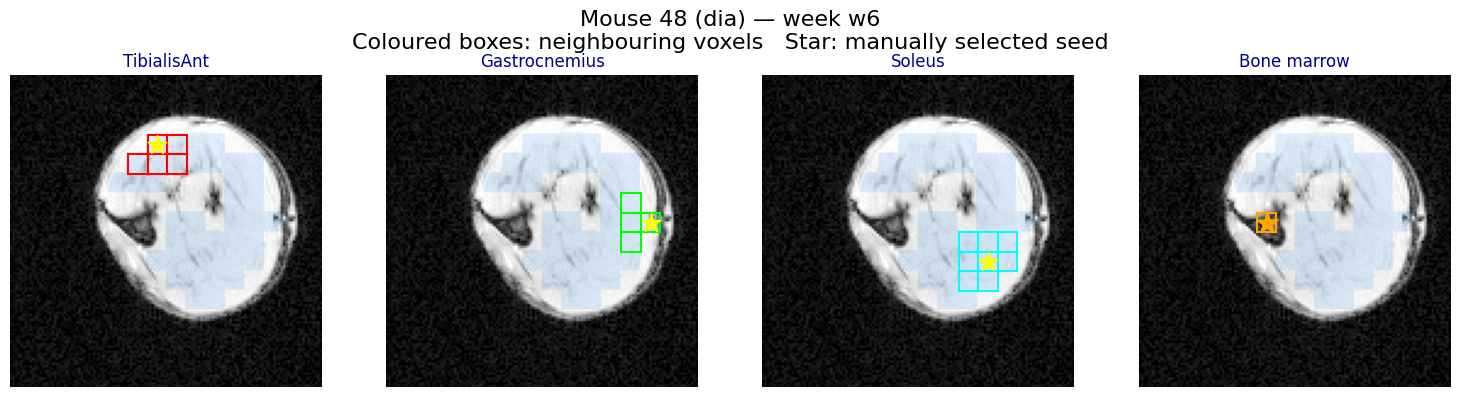

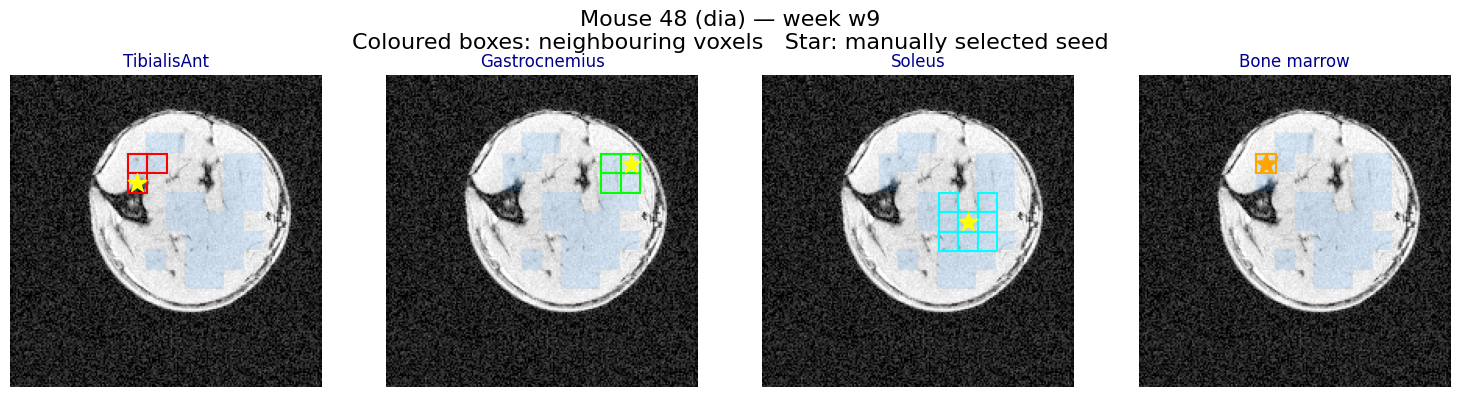

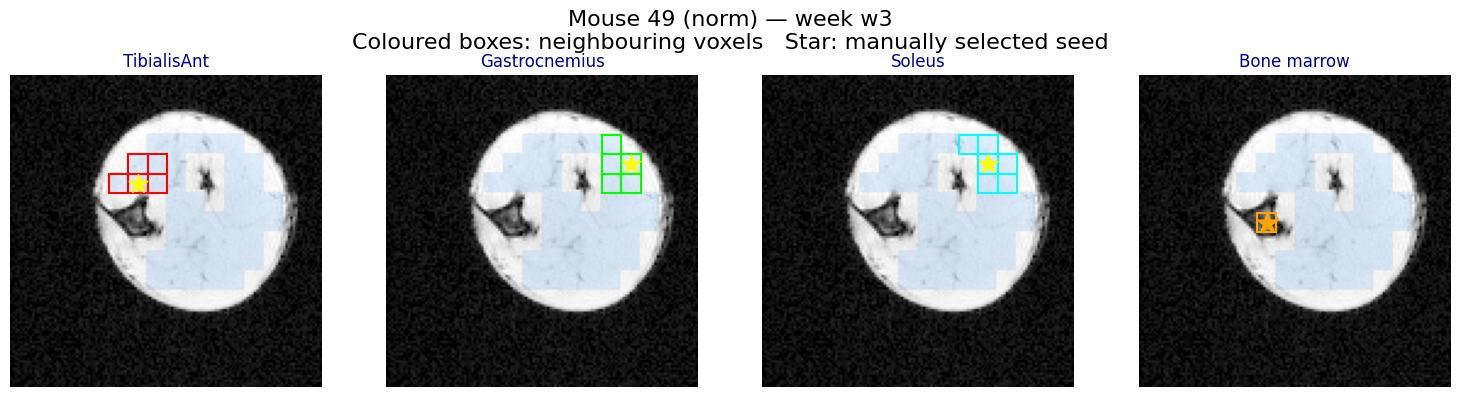

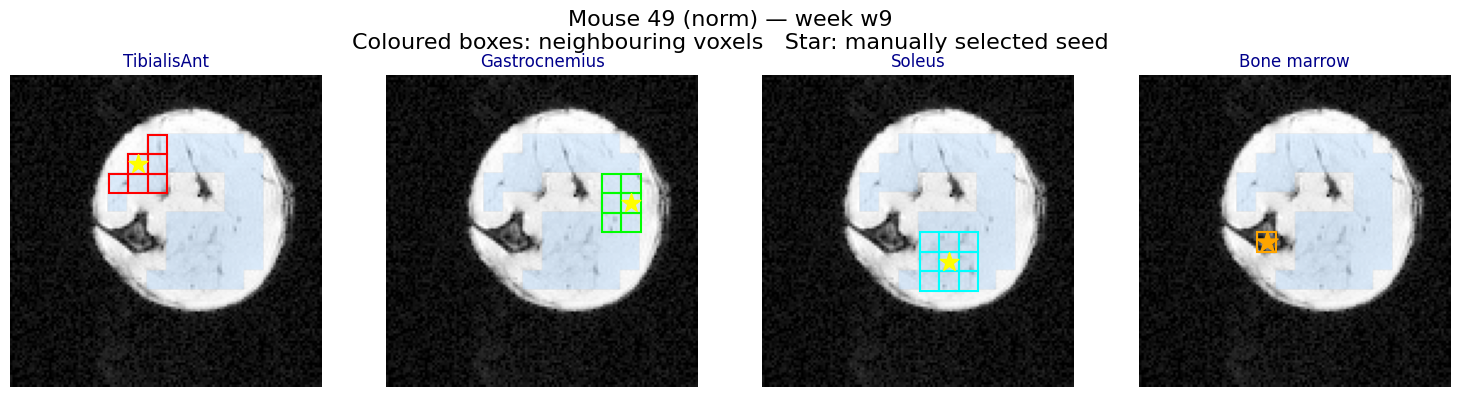

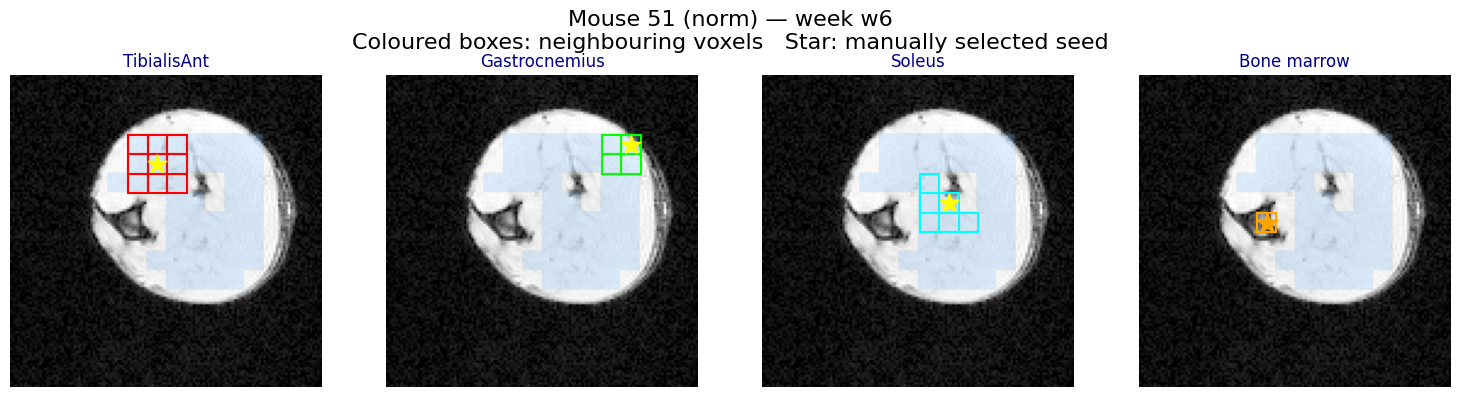

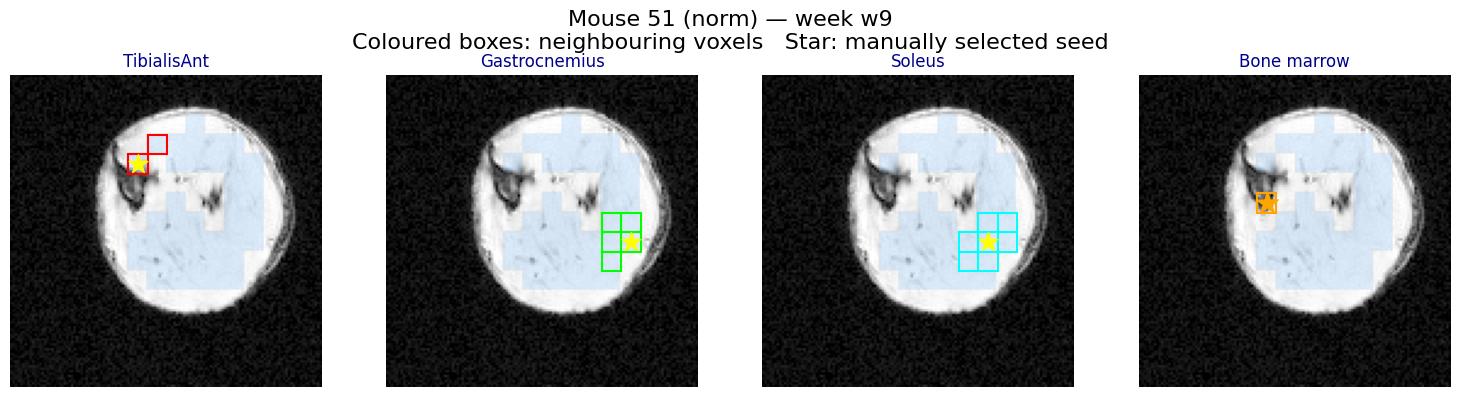

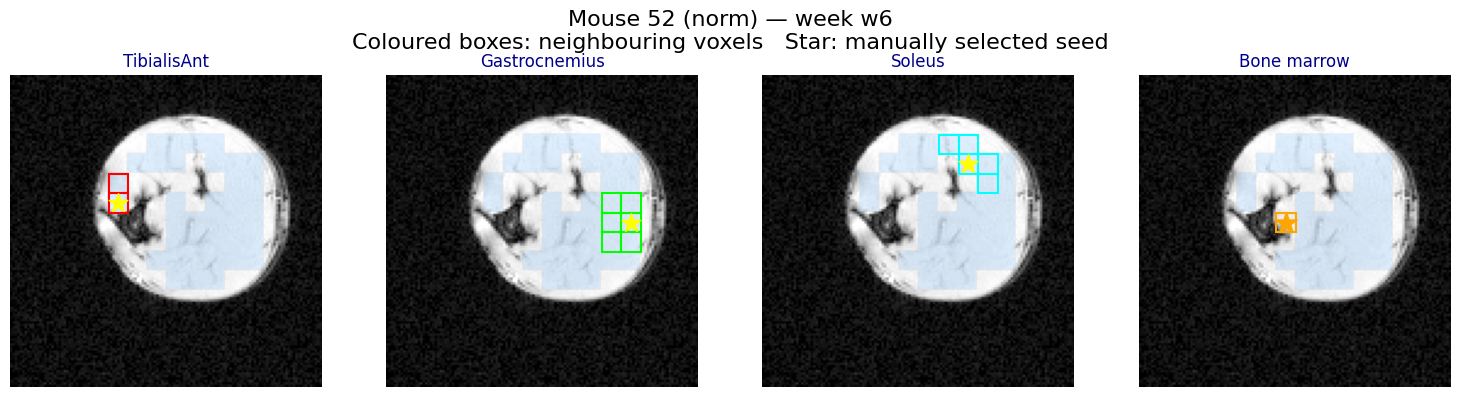

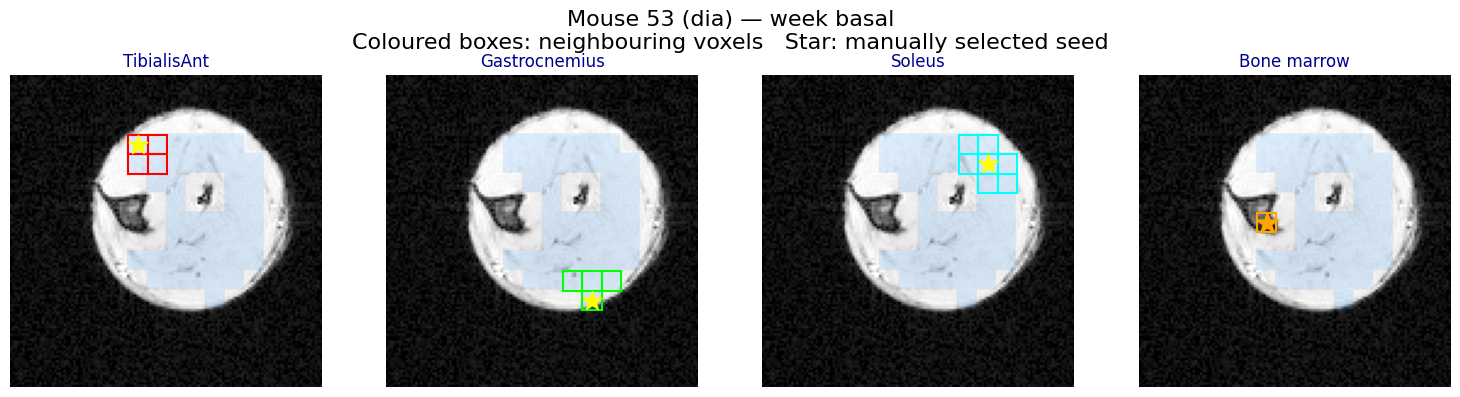

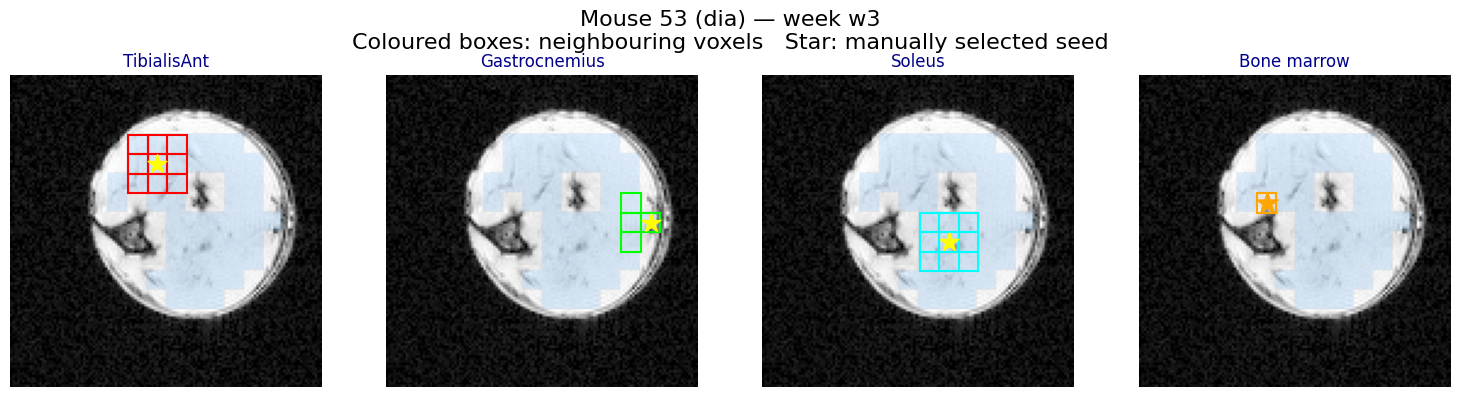

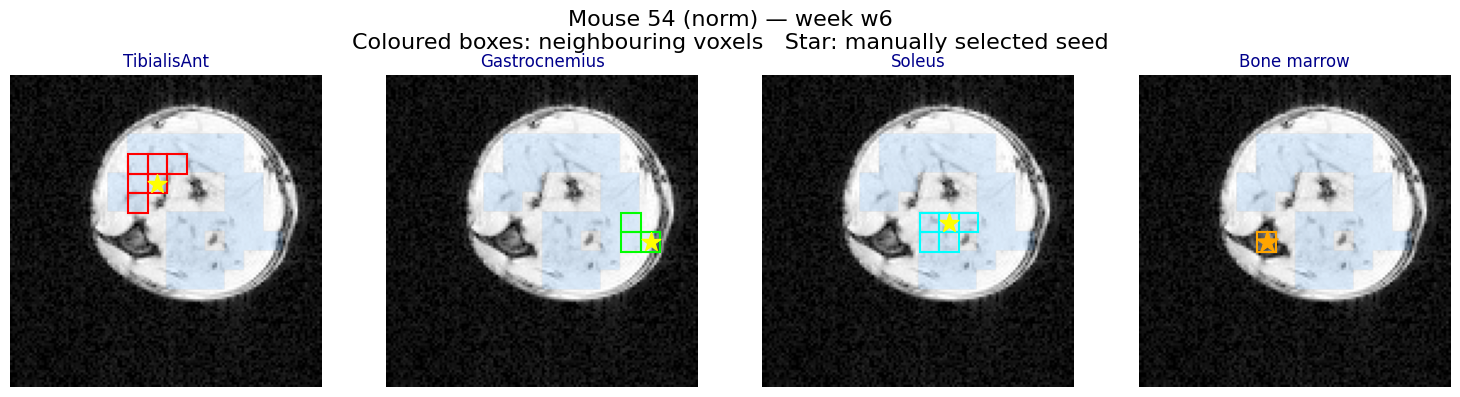

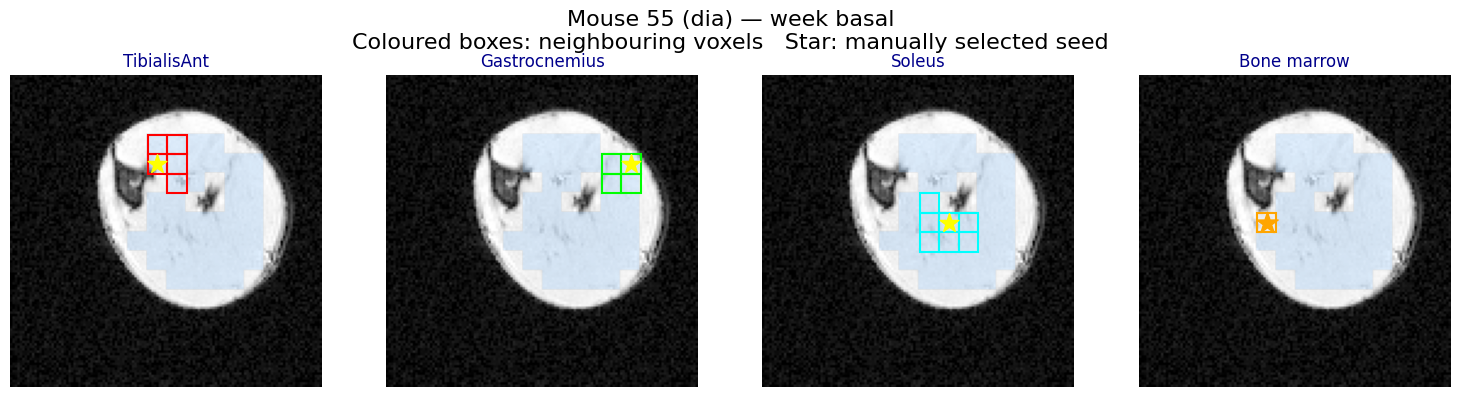

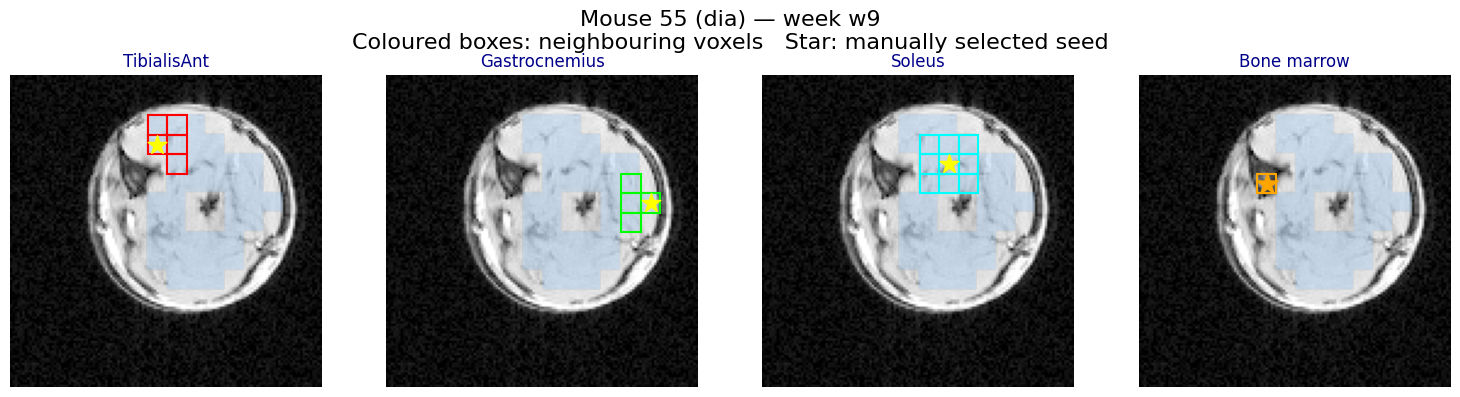

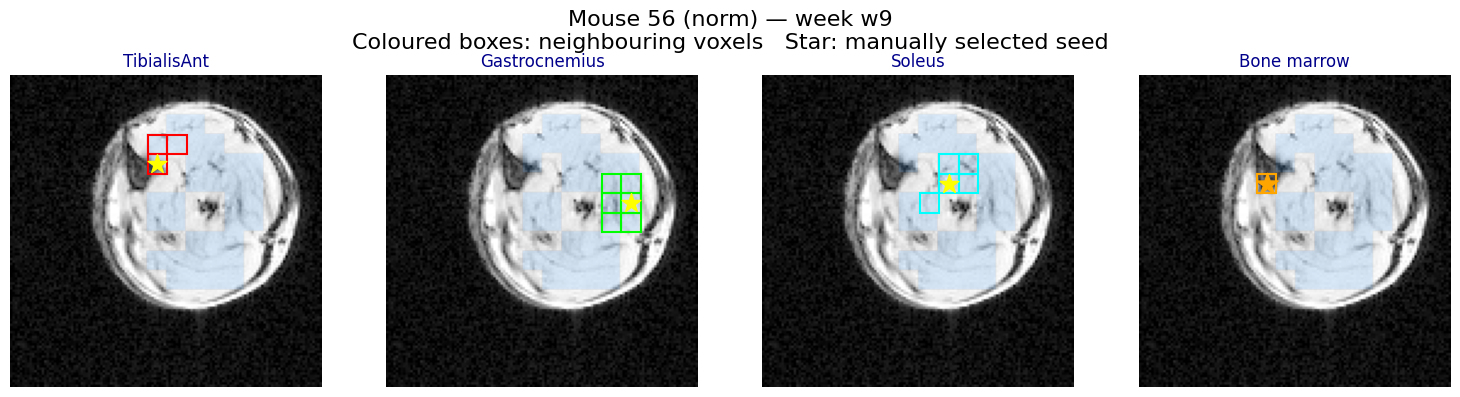

In [3]:
roi_masks_all = f_get_roi_masks()

# All tissues shown in the ROI overview (Knochenmark is reference-only, not fitted)
ALL_DISPLAY_TISSUES = ['TibialisAnt', 'Gastrocnemius', 'Soleus', 'Knochenmark']
TISSUE_EDGE_COLORS  = {
    'TibialisAnt':   'red',
    'Gastrocnemius': 'lime',
    'Soleus':        'cyan',
    'Knochenmark':   'orange',
}


def get_expanded_roi(tissue, week, mouseID, radius=ROI_RADIUS):
    """
    Return 0-based (row, col) voxel coordinates for the expanded ROI.

    Steps:
      1. Look up the manually annotated seed voxel in lib_roi_masks.
      2. Expand to all voxels within Chebyshev distance `radius`
         (radius=1 → up to 3×3 = 9 candidates).
      3. Intersect with the valid hindlimb mask (hash_mouseID2week2maskMap)
         so that only voxels inside the tissue segmentation are kept.

    Returns [] if the entry is missing or marked None (no valid ROI).
    """
    seed_mask = roi_masks_all.get(tissue, {}).get(week, {}).get(mouseID, None)
    if seed_mask is None:
        return []

    seed_rows, seed_cols = np.where(seed_mask)
    if len(seed_rows) == 0:
        return []
    r0, c0 = int(seed_rows[0]), int(seed_cols[0])

    # All voxels within Chebyshev ball of radius r
    candidates = [
        (r0 + dr, c0 + dc)
        for dr in range(-radius, radius + 1)
        for dc in range(-radius, radius + 1)
        if 0 <= r0 + dr < NX and 0 <= c0 + dc < NY
    ]

    tissue_mask = hash_mouseID2week2maskMap.get(mouseID, {}).get(week, None)
    if tissue_mask is None:
        return candidates
    return [(r, c) for r, c in candidates if tissue_mask[r, c]]


def get_seed_rc(tissue, week, mouseID):
    """Return (row, col) of the annotated seed voxel, or None."""
    seed_mask = roi_masks_all.get(tissue, {}).get(week, {}).get(mouseID, None)
    if seed_mask is None:
        return None
    rows, cols = np.where(seed_mask)
    if len(rows) == 0:
        return None
    return int(rows[0]), int(cols[0])


# ── ROI overview: one figure per (mouseID, week), 4 tissue columns ──────────
from skimage.transform import resize as sk_resize   # for mask upscaling

N_COL = len(ALL_DISPLAY_TISSUES)

for (mid, wk) in available_combos:
    anat = hash_mouseID2week2H1anatomical.get(mid, {}).get(wk, None)
    if anat is None:
        continue

    anat_h, anat_w = anat.shape
    scale_r = anat_h / NX
    scale_c = anat_w / NY

    grp  = hash_mouseID2group.get(mid, '?')
    fig, axes = plt.subplots(1, N_COL, figsize=(3.8 * N_COL, 4))

    for ax, tissue in zip(axes, ALL_DISPLAY_TISSUES):
        ax.imshow(anat, cmap='gray', origin='upper')

        # ── hindlimb mask (blue overlay) ──────────────────────────────────
        hmask = hash_mouseID2week2maskMap.get(mid, {}).get(wk, None)
        if hmask is not None:
            hmask_up = sk_resize(hmask.astype(float), (anat_h, anat_w), order=0)
            rgba = np.zeros((*hmask_up.shape, 4))
            rgba[hmask_up > 0.5] = [0.2, 0.6, 1.0, 0.15]
            ax.imshow(rgba, origin='upper')

        edge_col = TISSUE_EDGE_COLORS[tissue]

        if tissue == 'Knochenmark':
            # Bone marrow is shown as reference only (single seed point, no expansion)
            seed = get_seed_rc(tissue, wk, mid)
            if seed is not None:
                r, c = seed
                ax.scatter(
                    (c + 0.5) * scale_c, (r + 0.5) * scale_r,
                    marker='*', s=260, c='orange', zorder=5
                )
                ax.add_patch(plt.Rectangle(
                    (c * scale_c, r * scale_r), scale_c, scale_r,
                    linewidth=1.5, edgecolor=edge_col, facecolor='none', zorder=4
                ))
            n_vox_label = '(ref, not fitted)'
        else:
            # Fitted tissues: show seed star + expanded ROI boxes
            roi_coords = get_expanded_roi(tissue, wk, mid)
            seed = get_seed_rc(tissue, wk, mid)
            if seed is not None:
                r, c = seed
                ax.scatter(
                    (c + 0.5) * scale_c, (r + 0.5) * scale_r,
                    marker='*', s=200, c='yellow', zorder=5
                )
            for (r, c) in roi_coords:
                ax.add_patch(plt.Rectangle(
                    (c * scale_c, r * scale_r), scale_c, scale_r,
                    linewidth=1.5, edgecolor=edge_col, facecolor='none', zorder=4
                ))
            n_vox_label = f'{len(roi_coords)} voxels'

        # ax.set_title(f'{tissue}\n{n_vox_label}', fontsize=12, color=edge_col)
        ax.set_title(f'{tissue.replace("Knochenmark", "Bone marrow")}', fontsize=12, color='darkblue')
        ax.axis('off')

    # Legend (one per figure)
    legend_elements = [
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow',
                   markersize=10, label='Seed voxel (fitted tissues)'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='orange',
                   markersize=10, label='Bone marrow (reference)'),
    ]
    for tis, col in TISSUE_EDGE_COLORS.items():
        legend_elements.append(
            Patch(edgecolor=col, facecolor='none', linewidth=2, label=tis)
        )
    # axes[-1].legend(handles=legend_elements, fontsize=6.5,
    #                 loc='lower right', framealpha=0.7)

    fig.suptitle(
        f'Mouse {mid} ({grp}) — week {wk}\n'
        f'Coloured boxes: neighbouring voxels   Star: manually selected seed',
        fontsize=16
    )
    plt.tight_layout()
    plt.show()

# # Summary table
# print('\nROI voxel counts (radius=1):')
# for mid, wk in available_combos:
#     for tissue in TISSUES:
#         coords = get_expanded_roi(tissue, wk, mid)
#         if coords:
#             print(f'  Mouse {mid} {wk} {tissue}: {len(coords)} voxels')


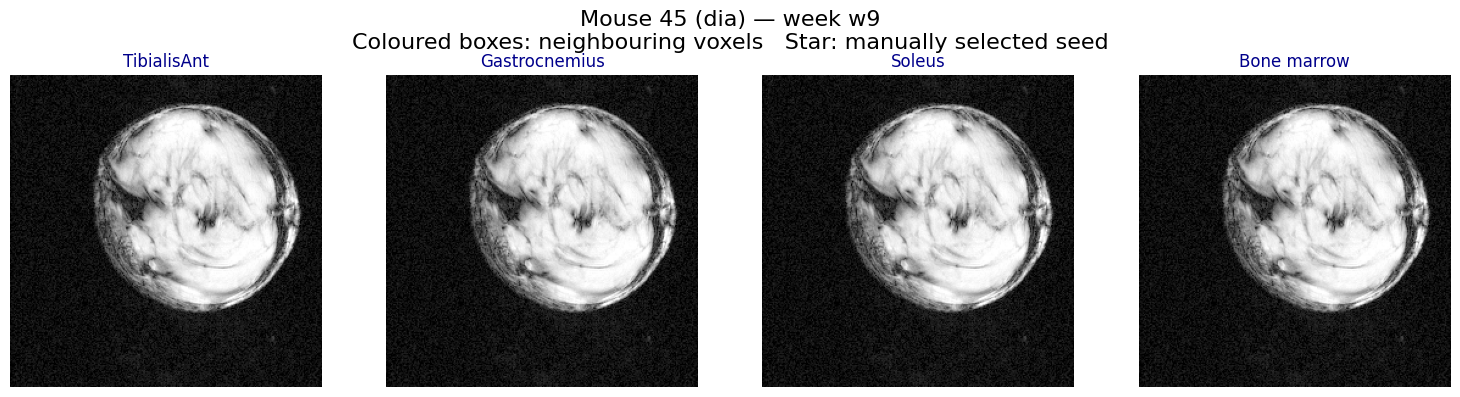

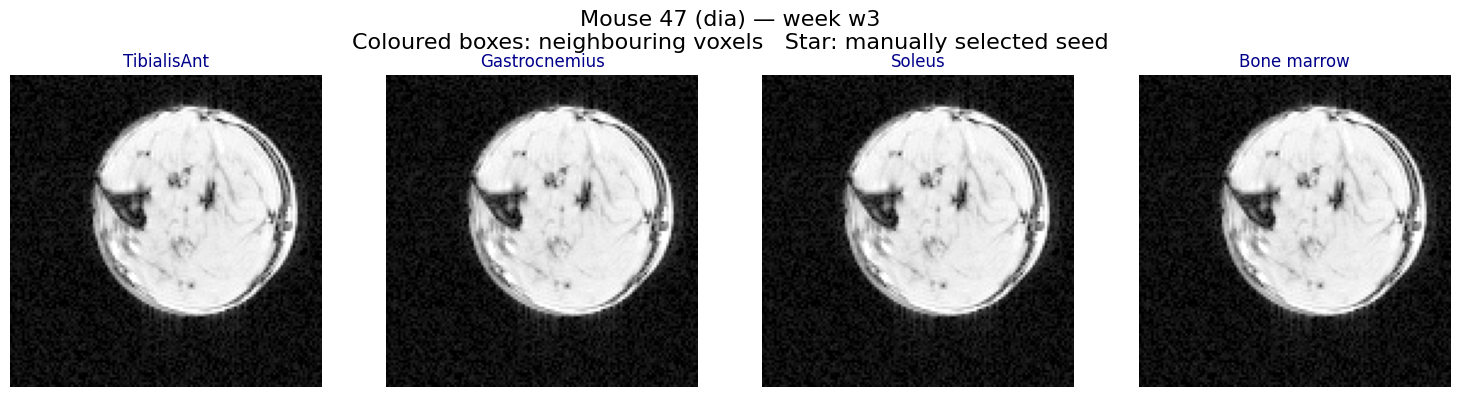

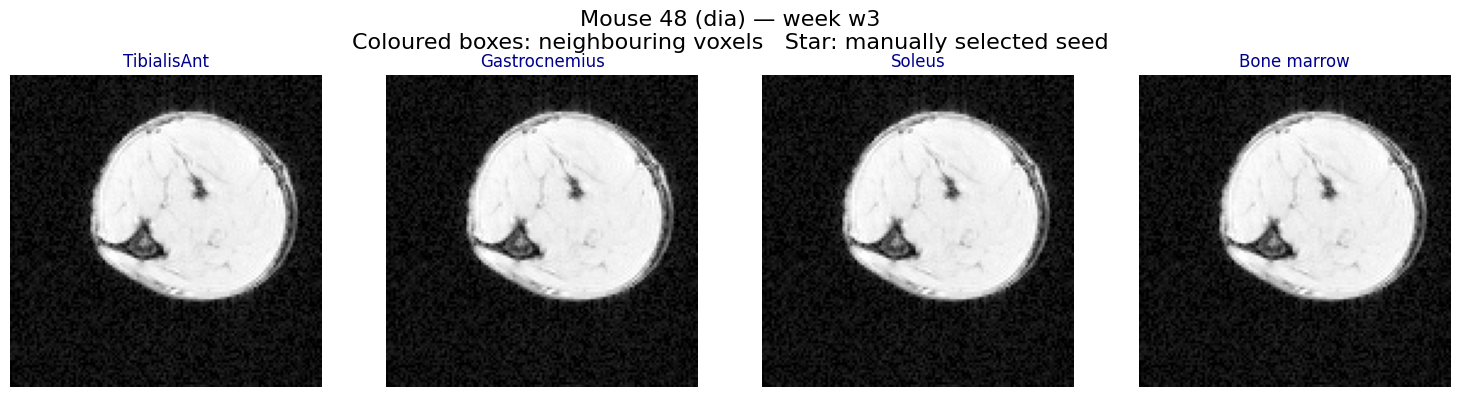

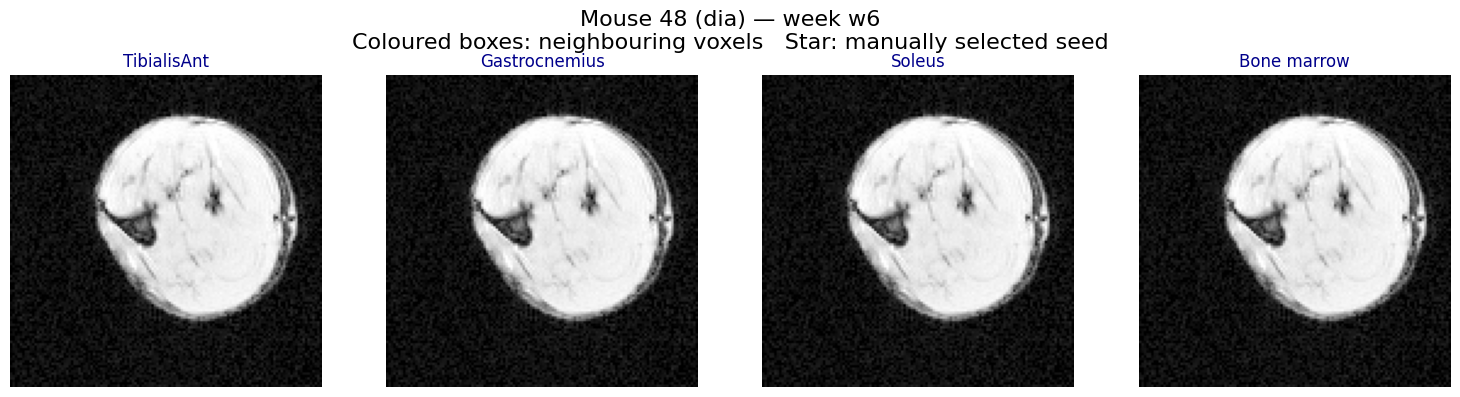

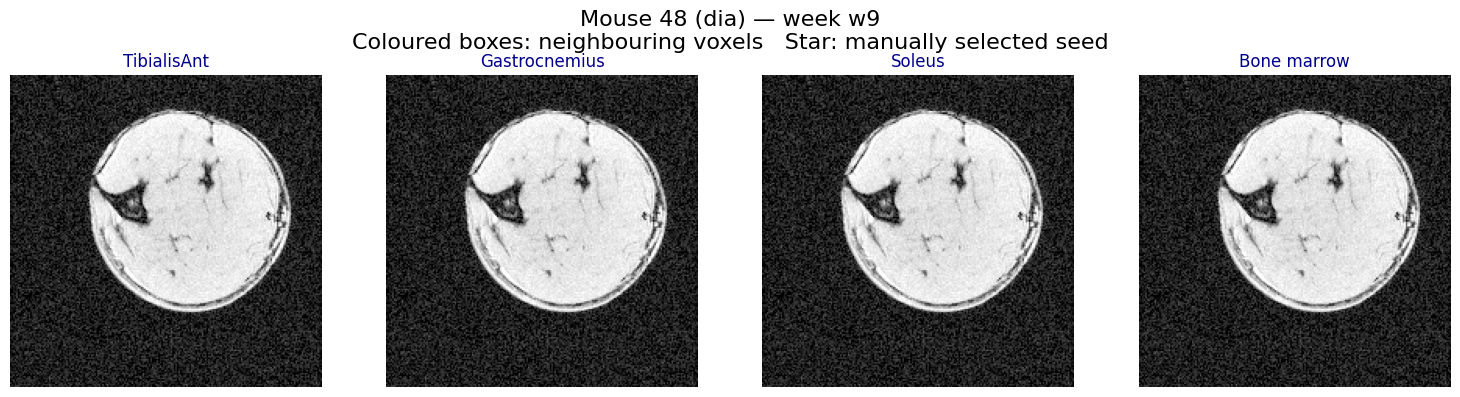

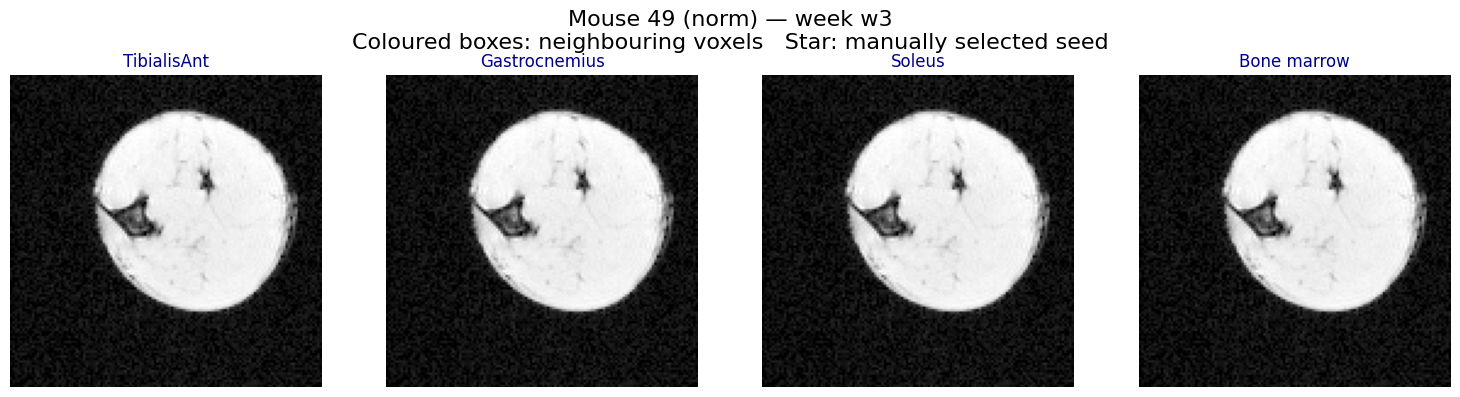

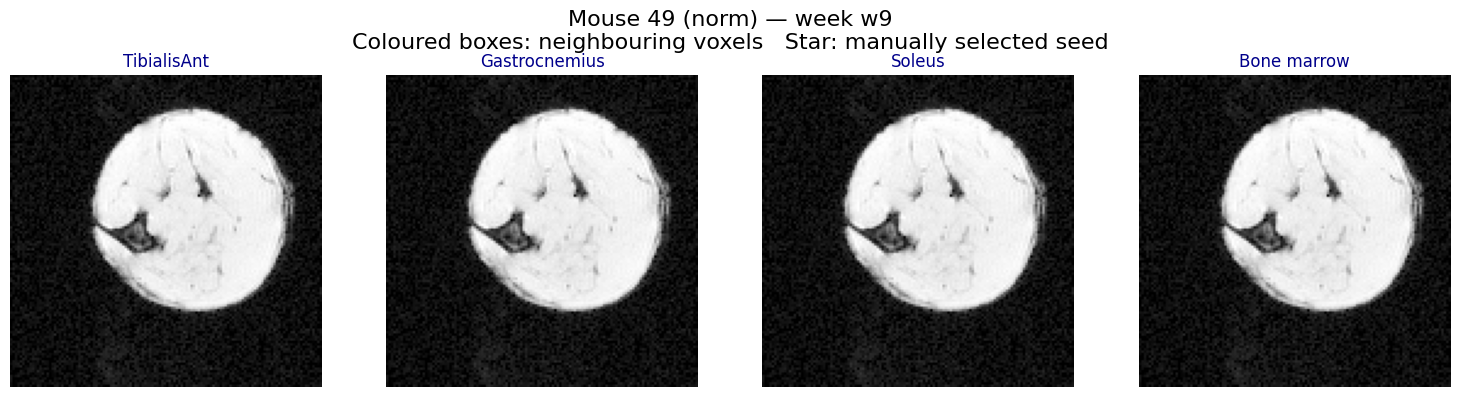

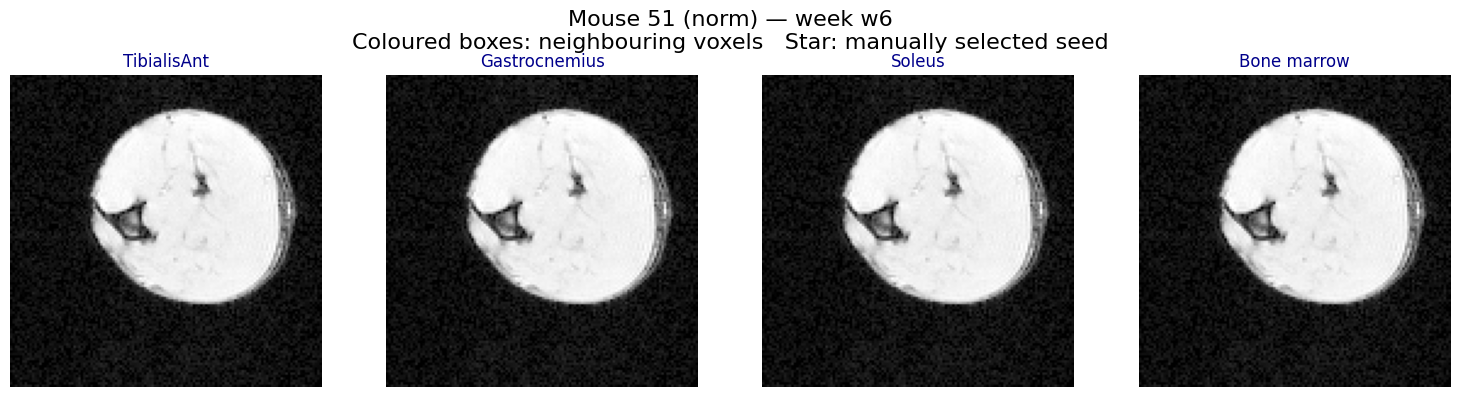

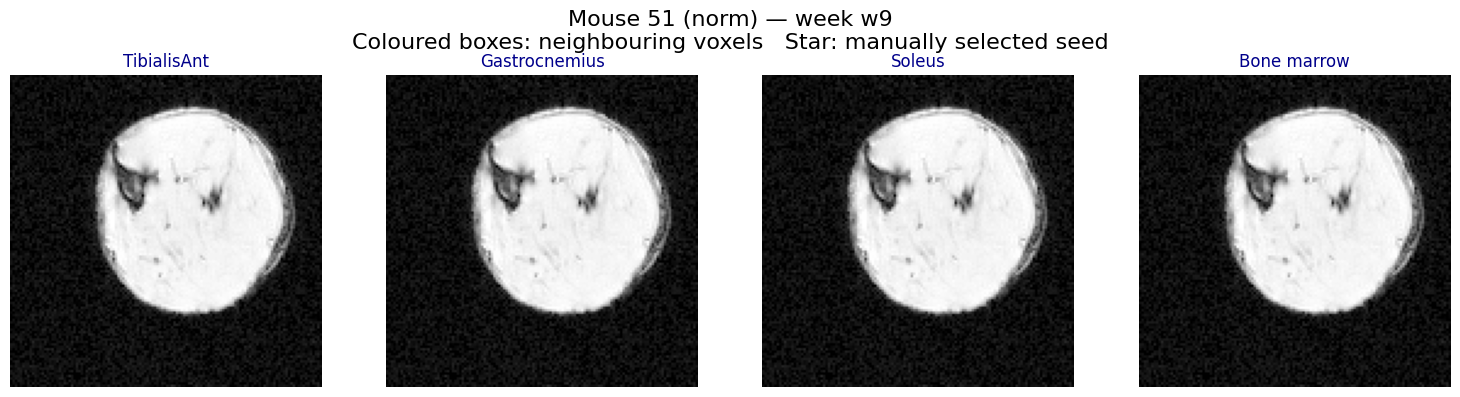

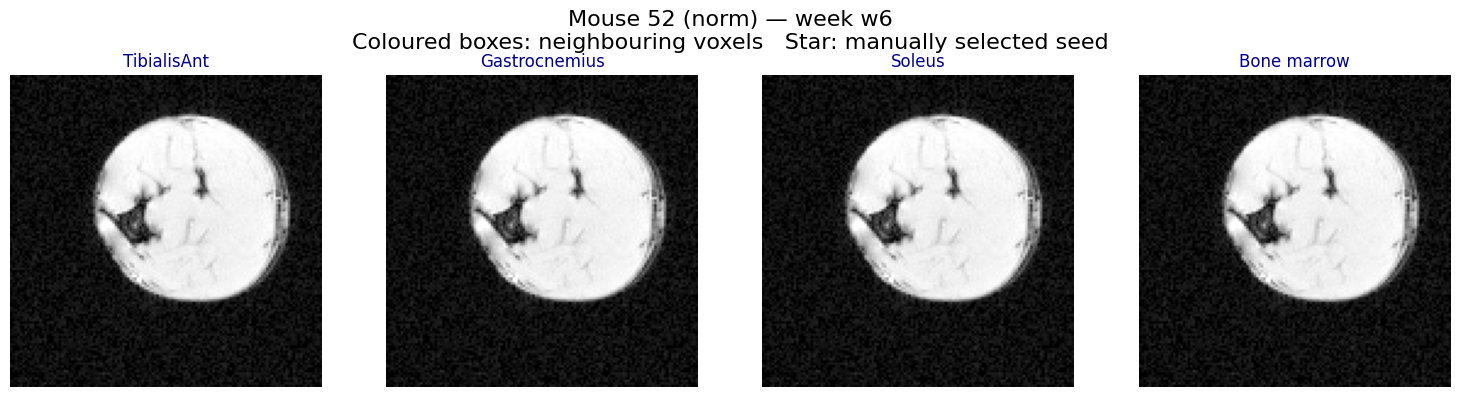

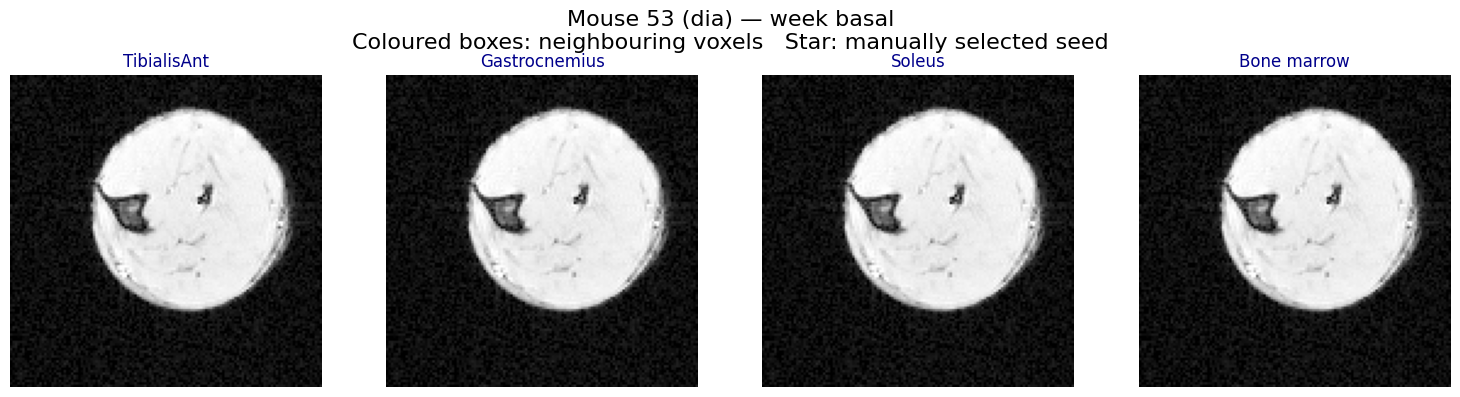

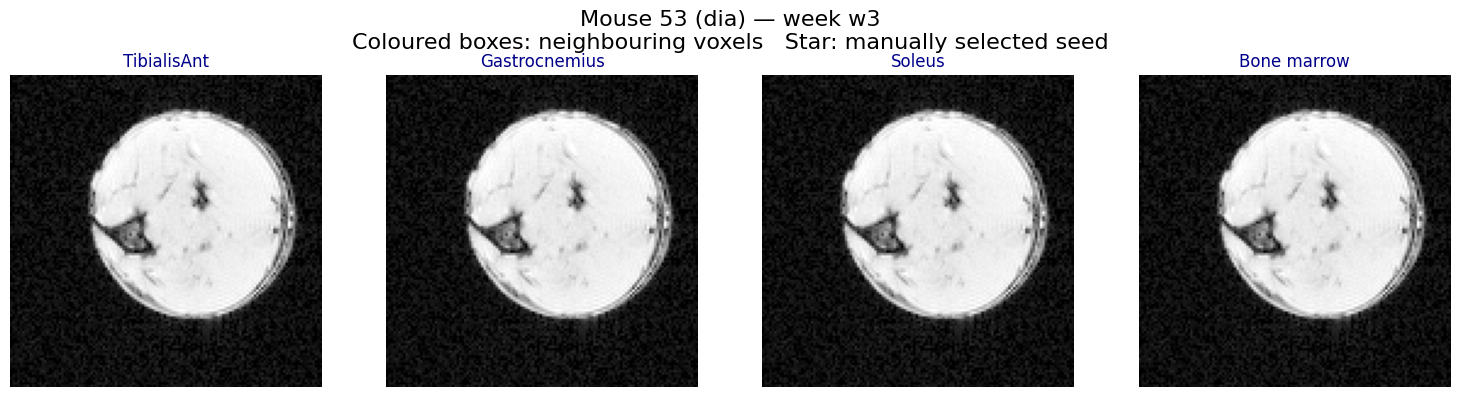

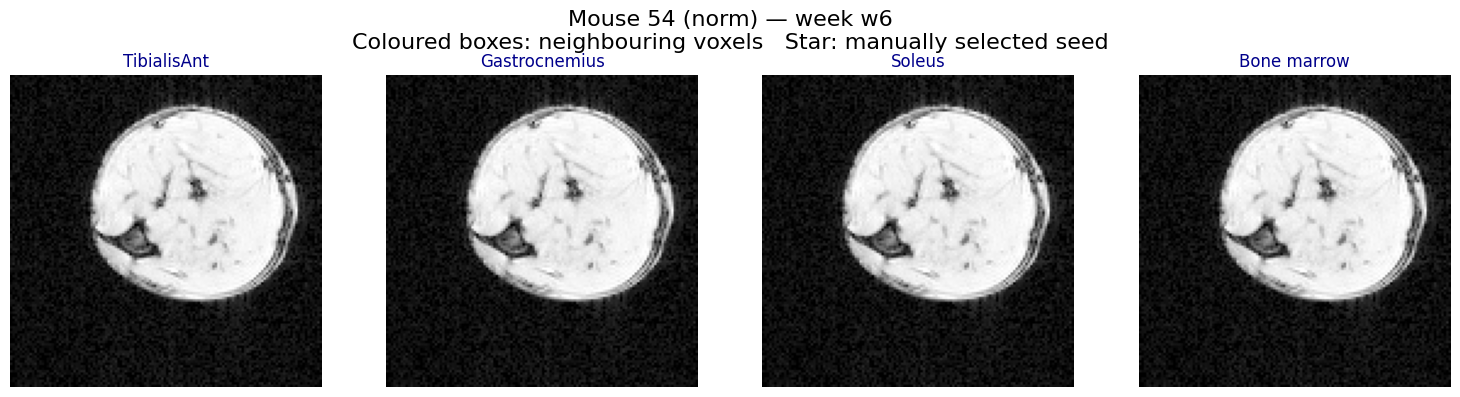

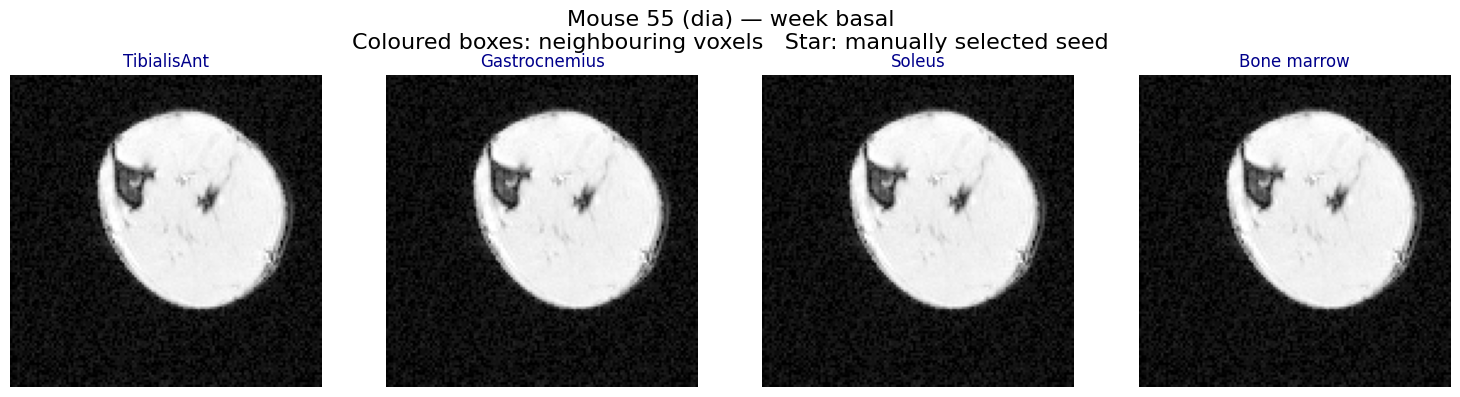

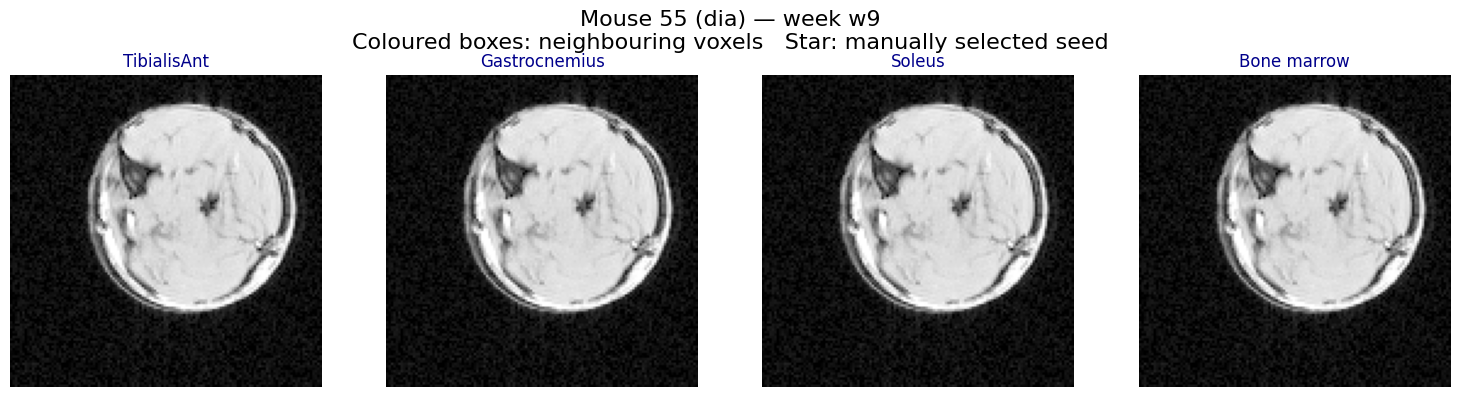

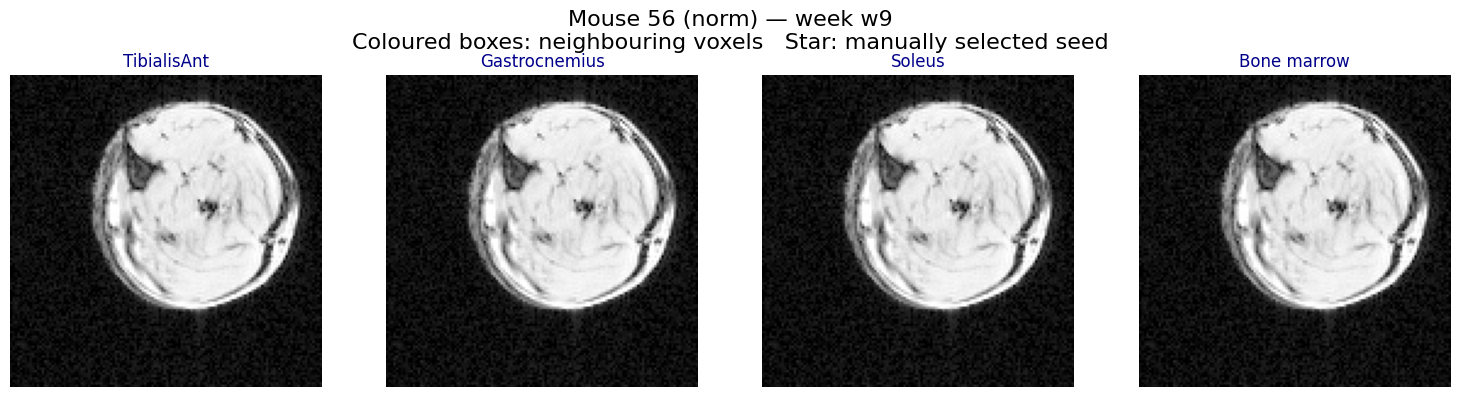

In [4]:
roi_masks_all = f_get_roi_masks()

# All tissues shown in the ROI overview (Knochenmark is reference-only, not fitted)
ALL_DISPLAY_TISSUES = ['TibialisAnt', 'Gastrocnemius', 'Soleus', 'Knochenmark']
TISSUE_EDGE_COLORS  = {
    'TibialisAnt':   'red',
    'Gastrocnemius': 'lime',
    'Soleus':        'cyan',
    'Knochenmark':   'orange',
}


def get_expanded_roi(tissue, week, mouseID, radius=ROI_RADIUS):
    """
    Return 0-based (row, col) voxel coordinates for the expanded ROI.

    Steps:
      1. Look up the manually annotated seed voxel in lib_roi_masks.
      2. Expand to all voxels within Chebyshev distance `radius`
         (radius=1 → up to 3×3 = 9 candidates).
      3. Intersect with the valid hindlimb mask (hash_mouseID2week2maskMap)
         so that only voxels inside the tissue segmentation are kept.

    Returns [] if the entry is missing or marked None (no valid ROI).
    """
    seed_mask = roi_masks_all.get(tissue, {}).get(week, {}).get(mouseID, None)
    if seed_mask is None:
        return []

    seed_rows, seed_cols = np.where(seed_mask)
    if len(seed_rows) == 0:
        return []
    r0, c0 = int(seed_rows[0]), int(seed_cols[0])

    # All voxels within Chebyshev ball of radius r
    candidates = [
        (r0 + dr, c0 + dc)
        for dr in range(-radius, radius + 1)
        for dc in range(-radius, radius + 1)
        if 0 <= r0 + dr < NX and 0 <= c0 + dc < NY
    ]

    tissue_mask = hash_mouseID2week2maskMap.get(mouseID, {}).get(week, None)
    if tissue_mask is None:
        return candidates
    return [(r, c) for r, c in candidates if tissue_mask[r, c]]


def get_seed_rc(tissue, week, mouseID):
    """Return (row, col) of the annotated seed voxel, or None."""
    seed_mask = roi_masks_all.get(tissue, {}).get(week, {}).get(mouseID, None)
    if seed_mask is None:
        return None
    rows, cols = np.where(seed_mask)
    if len(rows) == 0:
        return None
    return int(rows[0]), int(cols[0])


# ── ROI overview: one figure per (mouseID, week), 4 tissue columns ──────────
from skimage.transform import resize as sk_resize   # for mask upscaling

N_COL = len(ALL_DISPLAY_TISSUES)

for (mid, wk) in available_combos:
    anat = hash_mouseID2week2H1anatomical.get(mid, {}).get(wk, None)
    if anat is None:
        continue

    anat_h, anat_w = anat.shape
    scale_r = anat_h / NX
    scale_c = anat_w / NY

    grp  = hash_mouseID2group.get(mid, '?')
    fig, axes = plt.subplots(1, N_COL, figsize=(3.8 * N_COL, 4))

    for ax, tissue in zip(axes, ALL_DISPLAY_TISSUES):
        ax.imshow(anat, cmap='gray', origin='upper')

        # # ── hindlimb mask (blue overlay) ──────────────────────────────────
        # hmask = hash_mouseID2week2maskMap.get(mid, {}).get(wk, None)
        # if hmask is not None:
        #     hmask_up = sk_resize(hmask.astype(float), (anat_h, anat_w), order=0)
        #     rgba = np.zeros((*hmask_up.shape, 4))
        #     rgba[hmask_up > 0.5] = [0.2, 0.6, 1.0, 0.15]
        #     ax.imshow(rgba, origin='upper')

        # edge_col = TISSUE_EDGE_COLORS[tissue]

        # if tissue == 'Knochenmark':
        #     # Bone marrow is shown as reference only (single seed point, no expansion)
        #     seed = get_seed_rc(tissue, wk, mid)
        #     if seed is not None:
        #         r, c = seed
        #         ax.scatter(
        #             (c + 0.5) * scale_c, (r + 0.5) * scale_r,
        #             marker='*', s=260, c='orange', zorder=5
        #         )
        #         ax.add_patch(plt.Rectangle(
        #             (c * scale_c, r * scale_r), scale_c, scale_r,
        #             linewidth=1.5, edgecolor=edge_col, facecolor='none', zorder=4
        #         ))
        #     n_vox_label = '(ref, not fitted)'
        # else:
        #     # Fitted tissues: show seed star + expanded ROI boxes
        #     roi_coords = get_expanded_roi(tissue, wk, mid)
        #     seed = get_seed_rc(tissue, wk, mid)
        #     if seed is not None:
        #         r, c = seed
        #         ax.scatter(
        #             (c + 0.5) * scale_c, (r + 0.5) * scale_r,
        #             marker='*', s=200, c='yellow', zorder=5
        #         )
        #     for (r, c) in roi_coords:
        #         ax.add_patch(plt.Rectangle(
        #             (c * scale_c, r * scale_r), scale_c, scale_r,
        #             linewidth=1.5, edgecolor=edge_col, facecolor='none', zorder=4
        #         ))
        #     n_vox_label = f'{len(roi_coords)} voxels'

        # ax.set_title(f'{tissue}\n{n_vox_label}', fontsize=12, color=edge_col)
        ax.set_title(f'{tissue.replace("Knochenmark", "Bone marrow")}', fontsize=12, color='darkblue')
        ax.axis('off')

    # Legend (one per figure)
    legend_elements = [
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow',
                   markersize=10, label='Seed voxel (fitted tissues)'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='orange',
                   markersize=10, label='Bone marrow (reference)'),
    ]
    for tis, col in TISSUE_EDGE_COLORS.items():
        legend_elements.append(
            Patch(edgecolor=col, facecolor='none', linewidth=2, label=tis)
        )
    # axes[-1].legend(handles=legend_elements, fontsize=6.5,
    #                 loc='lower right', framealpha=0.7)

    fig.suptitle(
        f'Mouse {mid} ({grp}) — week {wk}\n'
        f'Coloured boxes: neighbouring voxels   Star: manually selected seed',
        fontsize=16
    )
    plt.tight_layout()
    plt.show()


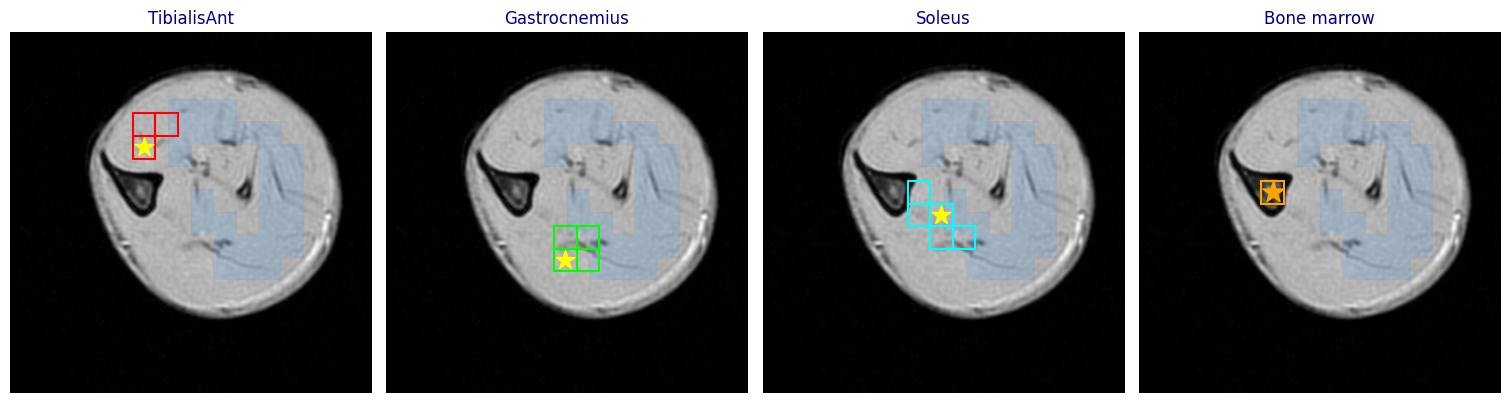

In [32]:
roi_masks_all = f_get_roi_masks()

# All tissues shown in the ROI overview (Knochenmark is reference-only, not fitted)
ALL_DISPLAY_TISSUES = ['TibialisAnt', 'Gastrocnemius', 'Soleus', 'Knochenmark']
TISSUE_EDGE_COLORS  = {
    'TibialisAnt':   'red',
    'Gastrocnemius': 'lime',
    'Soleus':        'cyan',
    'Knochenmark':   'orange',
}


def get_expanded_roi(tissue, week, mouseID, radius=ROI_RADIUS):
    """
    Return 0-based (row, col) voxel coordinates for the expanded ROI.

    Steps:
      1. Look up the manually annotated seed voxel in lib_roi_masks.
      2. Expand to all voxels within Chebyshev distance `radius`
         (radius=1 → up to 3×3 = 9 candidates).
      3. Intersect with the valid hindlimb mask (hash_mouseID2week2maskMap)
         so that only voxels inside the tissue segmentation are kept.

    Returns [] if the entry is missing or marked None (no valid ROI).
    """
    seed_mask = roi_masks_all.get(tissue, {}).get(week, {}).get(mouseID, None)
    if seed_mask is None:
        return []

    seed_rows, seed_cols = np.where(seed_mask)
    if len(seed_rows) == 0:
        return []
    r0, c0 = int(seed_rows[0]), int(seed_cols[0])

    # All voxels within Chebyshev ball of radius r
    candidates = [
        (r0 + dr, c0 + dc)
        for dr in range(-radius, radius + 1)
        for dc in range(-radius, radius + 1)
        if 0 <= r0 + dr < NX and 0 <= c0 + dc < NY
    ]

    tissue_mask = hash_mouseID2week2maskMap.get(mouseID, {}).get(week, None)
    if tissue_mask is None:
        return candidates
    return [(r, c) for r, c in candidates if tissue_mask[r, c]]


def get_seed_rc(tissue, week, mouseID):
    """Return (row, col) of the annotated seed voxel, or None."""
    seed_mask = roi_masks_all.get(tissue, {}).get(week, {}).get(mouseID, None)
    if seed_mask is None:
        return None
    rows, cols = np.where(seed_mask)
    if len(rows) == 0:
        return None
    return int(rows[0]), int(cols[0])


# ── ROI overview ──────────

# use only an externally provided image
from pathlib import Path
import numpy as np
from PIL import Image
png_path = Path("1H_ref.png")
tmp_anat = np.array(Image.open(png_path).convert("L"))  # grayscale, shape = (H, W)

shift_x = -80
shift_y = -20

from skimage.transform import resize as sk_resize   # for mask upscaling

N_COL = len(ALL_DISPLAY_TISSUES)

# for (mid, wk) in available_combos:
for (mid, wk) in [[45, 'w9']]:
    # anat = hash_mouseID2week2H1anatomical.get(mid, {}).get(wk, None)
    anat = tmp_anat
    if anat is None:
        continue

    anat_h, anat_w = anat.shape
    scale_r = anat_h / NX
    scale_c = anat_w / NY

    grp  = hash_mouseID2group.get(mid, '?')
    fig, axes = plt.subplots(1, N_COL, figsize=(3.8 * N_COL, 4))

    for ax, tissue in zip(axes, ALL_DISPLAY_TISSUES):
        ax.imshow(anat, cmap='gray', origin='upper')

        # ── hindlimb mask (blue overlay) ──────────────────────────────────
        hmask = hash_mouseID2week2maskMap.get(mid, {}).get(wk, None)
        if hmask is not None:
            hmask_up = sk_resize(hmask.astype(float), (anat_h, anat_w), order=0)
            rgba = np.zeros((*hmask_up.shape, 4))
            rgba[hmask_up > 0.5] = [0.2, 0.6, 1.0, 0.15]
            ax.imshow(rgba, origin='upper')

        edge_col = TISSUE_EDGE_COLORS[tissue]

        if tissue == 'Knochenmark':
            # Bone marrow is shown as reference only (single seed point, no expansion)
            seed = get_seed_rc(tissue, wk, mid)
            if seed is not None:
                r, c = seed
                ax.scatter(
                    (c + 0.5) * scale_c + shift_x, (r + 0.5) * scale_r + shift_y,
                    marker='*', s=260, c='orange', zorder=5
                )
                ax.add_patch(plt.Rectangle(
                    (c * scale_c + shift_x, r * scale_r + shift_y), scale_c, scale_r,
                    linewidth=1.5, edgecolor=edge_col, facecolor='none', zorder=4
                ))
            n_vox_label = '(ref, not fitted)'
        else:
            # Fitted tissues: show seed star + expanded ROI boxes
            roi_coords = get_expanded_roi(tissue, wk, mid)
            seed = get_seed_rc(tissue, wk, mid)
            if seed is not None:
                r, c = seed
                ax.scatter(
                    (c + 0.5) * scale_c + shift_x, (r + 0.5) * scale_r + shift_y,
                    marker='*', s=200, c='yellow', zorder=5
                )
            for (r, c) in roi_coords:
                ax.add_patch(plt.Rectangle(
                    (c * scale_c + shift_x, r * scale_r + shift_y), scale_c, scale_r,
                    linewidth=1.5, edgecolor=edge_col, facecolor='none', zorder=4
                ))
            n_vox_label = f'{len(roi_coords)} voxels'

        # ax.set_title(f'{tissue}\n{n_vox_label}', fontsize=12, color=edge_col)
        ax.set_title(f'{tissue.replace("Knochenmark", "Bone marrow")}', fontsize=12, color='darkblue')
        ax.axis('off')

    # Legend (one per figure)
    legend_elements = [
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow',
                   markersize=10, label='Seed voxel (fitted tissues)'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='orange',
                   markersize=10, label='Bone marrow (reference)'),
    ]
    for tis, col in TISSUE_EDGE_COLORS.items():
        legend_elements.append(
            Patch(edgecolor=col, facecolor='none', linewidth=2, label=tis)
        )
    # axes[-1].legend(handles=legend_elements, fontsize=6.5,
    #                 loc='lower right', framealpha=0.7)

    # fig.suptitle(
    #     f'Mouse {mid} ({grp}) — week {wk}\n'
    #     f'Coloured boxes: neighbouring voxels   Star: manually selected seed',
    #     fontsize=16
    # )
    plt.tight_layout()
    plt.show()


In [5]:
available_combos

[(45, 'w9'),
 (47, 'w3'),
 (48, 'w3'),
 (48, 'w6'),
 (48, 'w9'),
 (49, 'w3'),
 (49, 'w9'),
 (51, 'w6'),
 (51, 'w9'),
 (52, 'w6'),
 (53, 'basal'),
 (53, 'w3'),
 (54, 'w6'),
 (55, 'basal'),
 (55, 'w9'),
 (56, 'w9')]

In [7]:
anat

array([[0.10196079, 0.03137255, 0.12156863, ..., 0.03921569, 0.07058824,
        0.        ],
       [0.03137255, 0.        , 0.08627451, ..., 0.03921569, 0.        ,
        0.07450981],
       [0.07843138, 0.09019608, 0.0627451 , ..., 0.11764706, 0.06666667,
        0.        ],
       ...,
       [0.05882353, 0.        , 0.05490196, ..., 0.        , 0.08235294,
        0.05098039],
       [0.        , 0.08235294, 0.04313726, ..., 0.        , 0.03921569,
        0.05098039],
       [0.08627451, 0.06666667, 0.        , ..., 0.05098039, 0.        ,
        0.        ]], shape=(256, 256), dtype=float32)